# Wildfire → Solar · M3 — Damage (capex-weighted BoS curve on kW/m)

**Peril:** Wildfire · **Layer:** M3 (severity) · assets: Hayhurst (low-fire) + Matrix (high-fire).

Map the coupled **fire-line intensity (kW/m)** from M2 → a **capex-weighted BoS damage ratio**, then the
**conditional loss given a fire**. Like hail: a curated, **approximate** curve now (the InfraSure library),
accurate curves later. This is the InfraSure wedge — no incumbent has renewable-specific wildfire curves.

> Plan: [`docs/plans/wildfire/m3_damage.md`](../../../../docs/plans/wildfire/m3_damage.md) · Curve source:
> `infrasure-damage-curves` (canonical) · Decision **DD-W8** · [AW-19](../../../../docs/plans/wildfire/assumptions.md) (30% TIV).

## 1 · The curve (DD-W8) — InfraSure BoS-weighted, kW/m, **approximate**

**6 BoS subsystem** logistic curves `DRᵢ(I) = Lᵢ/(1+exp(−kᵢ(I−x0ᵢ)))` on Byram **kW/m**, from the canonical
`infrasure-damage-curves` (params read live; **not** the lab's hard-coded copy → no drift). **Channel-1
physical damage only** (smoke + PSPS are separate, deferred). Curated by component-threshold aggregation
(engineering thermal standards), **not fitted to our losses** → provenance is the deliverable.

- **Blend:** `Asset_DR(I) = Σ wᵢ·DRᵢ(I)`; weights sum **~0.70** → ~30% TIV unmodeled → **(A) non-damageable**
  (V1) ([AW-19](../../../../docs/plans/wildfire/assumptions.md); mirrors hail's partial cap).
- **Anchored (DD-W8 / AW-29):** the canonical *raw* logistics have a **non-physical floor** (`DRᵢ(0) ≈ 5–17%`
  — no fire, yet damage; thresholds aren't sharp, `k·x0 ≈ 1.5–2.7`). We **anchor** — subtract each curve's
  `DRᵢ(0)` so `DR(0)=0` — exactly as the legacy 'anchored logistic' did. Anchored cap ≈ **0.57** of TIV.
- **LOTV (basics-spot-on):** M3 emits the **conditional** loss (full loss *given a fire*); it does **NOT**
  multiply by occurrence/λ — M4's sampled engine reunites them. `loss% of TIV = Asset_DR × exposure`.
- **Approximate:** confidence **Low / Low-Med**, `d = 10 m` embedded (±40% — dominant uncertainty), zero
  empirical RE calibration. Accurate-curve revamp deferred.

In [1]:
from __future__ import annotations
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "wildfire"
SOLAR_TIV_PER_KWP = 1483.0      # InfraSure/lab approx $/kWp (TIV-basis unconfirmed — A19 analogue); for assets missing TIV

# --- load the 6 canonical curves (L/k/x0/confidence) from infrasure-damage-curves; weights = range midpoints ---
IDX = ROOT / "infrasure-damage-curves" / "data" / "master_curve_index.json"
grp = [h for h in json.loads(IDX.read_text())["hazard_groups"]
       if h.get("hazard_code") == "WILDFIRE" and h.get("asset_type") == "solar"][0]
CURVES = {c["subsystem"]: {"L": c["L"], "k": c["k"], "x0": c["x0"], "conf": c["confidence"]} for c in grp["curves"]}
# canonical index carries ranges, not point weights → use midpoints, and flag it (gap for the curve repo)
WEIGHTS = {"PV_ARRAY": 0.30, "MOUNTING": 0.10, "INVERTER_SYSTEM": 0.08, "SUBSTATION": 0.07, "ELECTRICAL": 0.08, "CIVIL_INFRA": 0.07}
W_SUM = sum(WEIGHTS.values())
print(f"curve source: {IDX.relative_to(ROOT)}  ·  axis: {grp['intensity_variable']} ({grp['intensity_unit']})")
print(f"note: {grp['notes']}\n")
print(f"{'subsystem':16s} {'w':>5s} {'L':>5s} {'k':>7s} {'x0':>6s}  conf")
for s, c in CURVES.items():
    print(f"{s:16s} {WEIGHTS[s]:5.2f} {c['L']:5.2f} {c['k']:7.4f} {c['x0']:6.0f}  {c['conf']}")
print(f"\nΣweights = {W_SUM:.2f}  → ~{100*(1-W_SUM):.0f}% of TIV unmodeled (V1: non-damageable — AW-19). "
      f"Weights are canonical-range midpoints (master_curve_index lacks point weights — flag for the curve repo).")


def dr_subsystem_raw(I, L, k, x0):
    return L / (1.0 + np.exp(-k * (I - x0)))


def dr_subsystem(I, L, k, x0):
    """ANCHORED subsystem damage ratio: raw logistic minus its I=0 floor → DR(0)=0 (DD-W8 / AW-29). The
    canonical curves' raw floor (`DR(0)=L/(1+e^{k·x0})` ≈ 5–17% here) is non-physical — no fire, yet damage —
    because the thresholds aren't sharp (`k·x0 ≈ 1.5–2.7`). We anchor it out, exactly as the legacy 'anchored
    logistic' did. (The accurate-curve revamp should ship sharper thresholds so the floor doesn't arise.)"""
    return np.maximum(0.0, dr_subsystem_raw(I, L, k, x0) - dr_subsystem_raw(0.0, L, k, x0))


def asset_dr(I):
    """Capex-weighted blend of the ANCHORED subsystem curves. I in kW/m → damage ratio (fraction of TIV)."""
    return sum(WEIGHTS[s] * dr_subsystem(I, c["L"], c["k"], c["x0"]) for s, c in CURVES.items())

curve source: infrasure-damage-curves/data/master_curve_index.json  ·  axis: fireline_intensity_kWm (kW/m)
note: Triple-channel loss: physical damage (modeled), smoke soiling (separate), PSPS (separate). Curves model Channel 1 only. Distance assumption d=10m.

subsystem            w     L       k     x0  conf
PV_ARRAY          0.30  0.95  0.0013   2100  low-medium
MOUNTING          0.10  0.80  0.0006   3600  low
INVERTER_SYSTEM   0.08  0.95  0.0021   1300  low-medium
SUBSTATION        0.07  0.95  0.0014   1900  low
ELECTRICAL        0.08  0.65  0.0008   2500  low
CIVIL_INFRA       0.07  0.75  0.0009   2100  low

Σweights = 0.70  → ~30% of TIV unmodeled (V1: non-damageable — AW-19). Weights are canonical-range midpoints (master_curve_index lacks point weights — flag for the curve repo).


## 2 · The curve, drawn — per-subsystem + the blended `Asset_DR(I)`

Saturating, **anchored** logistics on kW/m (`DR(0)=0`). The **inverter** (`x0=1300`) is the most vulnerable
(lowest threshold); the anchored blend caps near **~0.57** of TIV (the 30% unmodeled never burns). Asset
mean intensities marked.

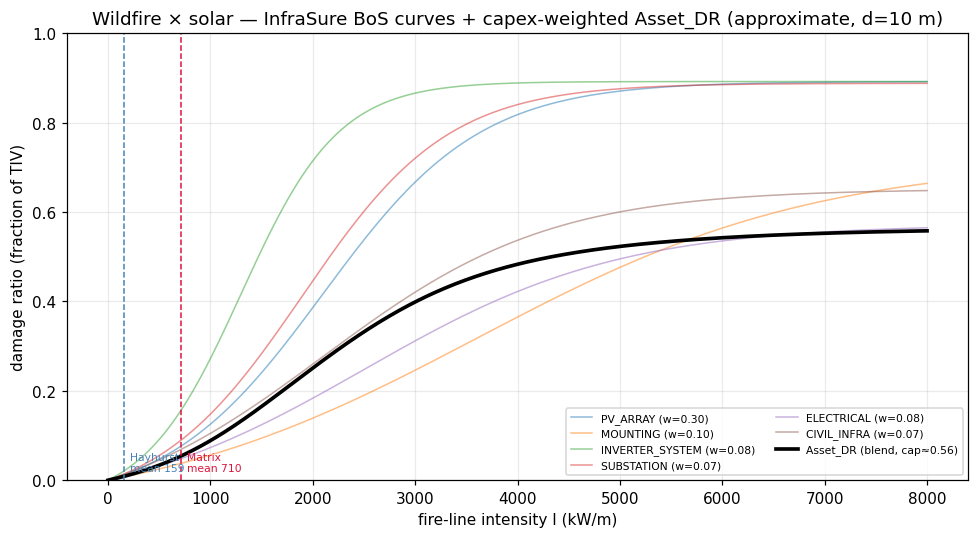

Asset_DR cap (saturation) = 0.564 of TIV  ·  Asset_DR(@Hayhurst mean 159) = 0.0088  ·  Asset_DR(@Matrix mean 710) = 0.0538


In [2]:
ASSETS = [("hayhurst_texas_solar", "Hayhurst Texas Solar", "baseline (low-fire)"),
          ("matrix_pleasant_valley", "Matrix Pleasant Valley", "proving (high-fire)")]
means = {}
for slug, _, _ in ASSETS:
    m1 = json.loads((DATA_DIR / f"{slug}_wildfire_m1_manifest.json").read_text())
    means[slug] = m1["conditional_mean_intensity_kwm"]

Igrid = np.linspace(0, 8000, 400)
fig, ax = plt.subplots(figsize=(9, 5))
for s, c in CURVES.items():
    ax.plot(Igrid, dr_subsystem(Igrid, c["L"], c["k"], c["x0"]), lw=1, alpha=0.5, label=f"{s} (w={WEIGHTS[s]:.2f})")
ax.plot(Igrid, asset_dr(Igrid), "k-", lw=2.4, label=f"Asset_DR (blend, cap≈{asset_dr(1e9):.2f})")
for slug, name, _ in ASSETS:
    ax.axvline(means[slug], ls="--", lw=1, color="crimson" if "matrix" in slug else "steelblue")
    ax.text(means[slug] + 60, 0.02, f"{name.split()[0]}\nmean {means[slug]:.0f}", fontsize=7,
            color="crimson" if "matrix" in slug else "steelblue")
ax.set_xlabel("fire-line intensity I (kW/m)"); ax.set_ylabel("damage ratio (fraction of TIV)")
ax.set_title("Wildfire × solar — InfraSure BoS curves + capex-weighted Asset_DR (approximate, d=10 m)")
ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 1); fig.tight_layout(); plt.show()
print(f"Asset_DR cap (saturation) = {asset_dr(1e9):.3f} of TIV  ·  Asset_DR(@Hayhurst mean {means['hayhurst_texas_solar']:.0f}) "
      f"= {asset_dr(means['hayhurst_texas_solar']):.4f}  ·  Asset_DR(@Matrix mean {means['matrix_pleasant_valley']:.0f}) "
      f"= {asset_dr(means['matrix_pleasant_valley']):.4f}")

## 3 · Per-class conditional damage + conditional loss (given a fire)

Evaluate `Asset_DR` at **each FLP class's kW/m** (M2's conditional severity) → per-class DR → conditional
loss. `loss% of TIV = Asset_DR × exposure` (TIV-free); dollars where TIV is known (Matrix TIV estimated via
$/kWp — flagged). **No ×λ here** (LOTV — that's M4).

In [3]:
dmg = {}
for slug, name, role in ASSETS:
    cpl = pd.read_parquet(DATA_DIR / f"{slug}_wildfire_m2_coupled.parquet")          # flame_class_ft, intensity_kwm, prob_given_fire, exposure_fraction
    m1 = json.loads((DATA_DIR / f"{slug}_wildfire_m1_manifest.json").read_text())
    tiv = m1["asset"].get("tiv_usd")
    tiv_est = tiv is None
    if tiv_est:
        tiv = (m1["asset"]["dc_mw"] * 1000.0) * SOLAR_TIV_PER_KWP                     # estimate via $/kWp (flagged)
    cpl = cpl.copy()
    cpl["asset_dr"] = asset_dr(cpl["intensity_kwm"].to_numpy())
    cpl["cond_loss_pct_tiv"] = cpl["asset_dr"] * cpl["exposure_fraction"]             # loss/TIV given this class burns
    cpl["cond_loss_usd"] = cpl["cond_loss_pct_tiv"] * tiv
    dmg[slug] = {"name": name, "role": role, "tiv": tiv, "tiv_est": tiv_est, "table": cpl,
                 "exposure": float(cpl["exposure_fraction"].iloc[0])}
    print(f"\n=== {name} ({role})  TIV={'~$'+format(tiv,',.0f')+' (est via $/kWp)' if tiv_est else '$'+format(tiv,',.0f')} ===")
    print(cpl[["flame_class_ft", "intensity_kwm", "prob_given_fire", "asset_dr", "cond_loss_pct_tiv"]].round(5).to_string(index=False))


=== Hayhurst Texas Solar (baseline (low-fire))  TIV=$36,778,400 ===
flame_class_ft  intensity_kwm  prob_given_fire  asset_dr  cond_loss_pct_tiv
            <2           19.6          0.52815   0.00100            0.00100
           2–4          213.8          0.37204   0.01216            0.01216
           4–6          649.2          0.09611   0.04747            0.04747
           6–8         1349.0          0.00250   0.14012            0.14012
          8–12         2929.3          0.00120   0.39030            0.39030
           12+         7072.5          0.00000   0.55294            0.55294

=== Matrix Pleasant Valley (proving (high-fire))  TIV=~$385,580,000 (est via $/kWp) ===
flame_class_ft  intensity_kwm  prob_given_fire  asset_dr  cond_loss_pct_tiv
            <2           19.6          0.00250   0.00100            0.00100
           2–4          213.8          0.33587   0.01216            0.01216
           4–6          649.2          0.45525   0.04747            0.04747
      

## 4 · Conditional `E[DR | fire]` and the conditional loss (the M4 severity input)

`E[DR|fire] = Σ P(class|fire)·Asset_DR(class)`. The conditional loss (given a fire) as % of TIV is
`E[DR|fire] × exposure`. This + λ (M1/M2) is what M4's compound engine samples.

In [4]:
rows = []
for slug, d in dmg.items():
    t = d["table"]
    e_dr = float((t["prob_given_fire"] * t["asset_dr"]).sum())
    cond_loss_pct = e_dr * d["exposure"]
    rows.append({"asset": d["name"], "role": d["role"], "E[DR|fire]": round(e_dr, 5),
                 "cond_loss_%TIV|fire": round(100 * cond_loss_pct, 3),
                 "cond_loss_$|fire": round(cond_loss_pct * d["tiv"], 0),
                 "TIV_est?": d["tiv_est"]})
    dmg[slug]["e_dr"] = e_dr; dmg[slug]["cond_loss_pct"] = cond_loss_pct
con = pd.DataFrame(rows).set_index("asset")
print("Conditional severity given a fire (the M4 input):\n")
print(con.to_string())
print(f"\nContrast: Matrix E[DR|fire] / Hayhurst = "
      f"{dmg['matrix_pleasant_valley']['e_dr']/max(dmg['hayhurst_texas_solar']['e_dr'],1e-12):.0f}×  "
      f"— the low-vs-high severity gap, now in damage terms.")

Conditional severity given a fire (the M4 input):

                                       role  E[DR|fire]  cond_loss_%TIV|fire  cond_loss_$|fire  TIV_est?
asset                                                                                                   
Hayhurst Texas Solar    baseline (low-fire)     0.01043                1.043          383657.0     False
Matrix Pleasant Valley  proving (high-fire)     0.06464                6.464        24922300.0      True

Contrast: Matrix E[DR|fire] / Hayhurst = 6×  — the low-vs-high severity gap, now in damage terms.


## 5 · Known-answer + verification (basics spot-on)

In [5]:
# hand-compute Asset_DR at I = 2000 kW/m (active chaparral) and confirm the blend
I_chk = 2000.0
def _raw(I, c): return c["L"] / (1 + math.exp(-c["k"] * (I - c["x0"])))
by_hand = sum(WEIGHTS[s] * (_raw(I_chk, c) - _raw(0.0, c)) for s, c in CURVES.items())   # ANCHORED
assert abs(by_hand - asset_dr(I_chk)) < 1e-9, "blend mismatch"
assert asset_dr(0.0) < 1e-9, "anchored DR(0) must be 0"
print(f"known-answer: anchored Asset_DR(2000 kW/m) = {asset_dr(I_chk):.4f}  (hand-recompute matches ✓)")
print(f"DR bounds: Asset_DR(0)={asset_dr(0.0):.5f} (=0, anchored ✓) · cap Asset_DR(1e9)={asset_dr(1e9):.4f} · monotone ↑ ✓")
for slug, d in dmg.items():
    t = d["table"]
    assert (t["asset_dr"].between(0, 1)).all(), "DR must be in [0,1]"
    assert (t["cond_loss_pct_tiv"].between(0, 1)).all(), "loss%TIV must be in [0,1]"
    assert abs(t["prob_given_fire"].sum() - 1.0) < 1e-4
    print(f"{d['name']:24s}: DR∈[0,1] ✓ · loss%∈[0,1] ✓ · Σprob=1 ✓ · no ×λ (LOTV — conditional only) ✓")

known-answer: anchored Asset_DR(2000 kW/m) = 0.2509  (hand-recompute matches ✓)
DR bounds: Asset_DR(0)=0.00000 (=0, anchored ✓) · cap Asset_DR(1e9)=0.5642 · monotone ↑ ✓
Hayhurst Texas Solar    : DR∈[0,1] ✓ · loss%∈[0,1] ✓ · Σprob=1 ✓ · no ×λ (LOTV — conditional only) ✓
Matrix Pleasant Valley  : DR∈[0,1] ✓ · loss%∈[0,1] ✓ · Σprob=1 ✓ · no ×λ (LOTV — conditional only) ✓


## 6 · Emit per-asset M3 outputs + carry forward

In [6]:
for slug, d in dmg.items():
    out_pq = DATA_DIR / f"{slug}_wildfire_m3_damage.parquet"
    d["table"][["flame_class_ft", "intensity_kwm", "prob_given_fire", "asset_dr", "cond_loss_pct_tiv", "cond_loss_usd"]].to_parquet(out_pq, index=False)
    summary = {
        "layer": "M3", "candidate": "01_damage", "peril": "wildfire",
        "asset": {"slug": slug, "name": d["name"], "role": d["role"], "tiv_usd": d["tiv"], "tiv_estimated": d["tiv_est"]},
        "curve": {"source": "infrasure-damage-curves (canonical) — WILDFIRE × solar", "decision": "DD-W8",
                  "form": "logistic DR=L/(1+exp(-k(I-x0))) on Byram kW/m, capex-weighted blend",
                  "channel": "Channel-1 physical only (smoke/PSPS separate, deferred)", "distance_d_m": 10,
                  "anchored": "yes — each subsystem minus DR(0) so DR(0)=0 (DD-W8/AW-29); canonical raw floor (~5%) removed",
                  "confidence": "Low / Low-Medium; d=10m ±40%; zero empirical RE calibration (approximate)"},
        "subsystems": {s: {**CURVES[s], "weight": WEIGHTS[s]} for s in CURVES},
        "weights_sum": round(W_SUM, 3), "tiv_unmodeled_pct": round(100 * (1 - W_SUM), 1),
        "asset_dr_cap": round(float(asset_dr(1e9)), 4),
        "conditional_E_DR_given_fire": round(d["e_dr"], 5),
        "conditional_loss_pct_tiv_given_fire": round(100 * d["cond_loss_pct"], 3),
        "exposure_fraction": d["exposure"],
        "for_M4": "compound Poisson(λ from M1/M2) over this per-class conditional loss distribution; metrics off the SAMPLED dist",
        "caveats": ["approximate curve (Low/Low-Med conf; d=10m ±40%) — revamp deferred (DD-W8)",
                    "30% TIV unmodeled → non-damageable in V1 (AW-19); cap ~61% TIV",
                    "weights = canonical-range midpoints (index lacks point weights — flag for curve repo)",
                    "scalar DR per class — conditional-DR distribution deferred",
                    "Matrix TIV estimated via $/kWp" if d["tiv_est"] else "TIV from registry"],
    }
    (DATA_DIR / f"{slug}_wildfire_m3_summary.json").write_text(json.dumps(summary, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} + summary  ·  E[DR|fire]={d['e_dr']:.4f} · cond loss={100*d['cond_loss_pct']:.2f}% TIV")

print("\nM3 COMPLETE (both assets). Carried forward → M4: λ (M1) + the per-class conditional loss distribution "
      "(this M3) → shared compound-Poisson Monte-Carlo → EAL/VaR/PML/TVaR off the SAMPLED distribution, % of TIV.")

wrote data/wildfire/hayhurst_texas_solar_wildfire_m3_damage.parquet + summary  ·  E[DR|fire]=0.0104 · cond loss=1.04% TIV
wrote data/wildfire/matrix_pleasant_valley_wildfire_m3_damage.parquet + summary  ·  E[DR|fire]=0.0646 · cond loss=6.46% TIV

M3 COMPLETE (both assets). Carried forward → M4: λ (M1) + the per-class conditional loss distribution (this M3) → shared compound-Poisson Monte-Carlo → EAL/VaR/PML/TVaR off the SAMPLED distribution, % of TIV.
